In [2]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from models import EEGNet

In [3]:
device = torch.device(
    "cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cuda')

In [ ]:


X_list = []
y_list = []

datasets = ["dataset_155619"]  # "dataset_152626"]

for dataset in datasets:
    data = np.load(f"data/yo/{dataset}.npz")
    X_list.append(data["X"])  # (Trials, TimeSteps, Channels)
    y_list.append(data["y"])  # (Trials,)

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)

print(X.shape)
print(y.shape)

(6, 1, 8, 1000)
(6,)


In [7]:
import matplotlib.pyplot as plt

In [5]:
X.max()

np.float32(177056.22)

In [18]:
import numpy as np
from scipy.signal import butter, iirnotch, sosfiltfilt, filtfilt

# -------------------------
# Parameters
# -------------------------
fs = 250
lowcut = 8.0
highcut = 30.0
notch_freq = 50.0  # Use 60.0 if your recordings are from a 60 Hz region
quality = 30.0    # Notch filter Q factor

# -------------------------
# Design filters
# -------------------------
# 4th-order Butterworth bandpass
sos = butter(
    N=6,
    Wn=[lowcut, highcut],
    btype="bandpass",
    fs=fs,
    output="sos"
)

# Notch filter
b_notch, a_notch = iirnotch(
    w0=notch_freq,
    Q=quality,
    fs=fs
)

# -------------------------
# Apply filters
# -------------------------
# Filter along the time axis (axis=1)
X_filtered = sosfiltfilt(sos, X, axis=-1)
X_filtered = filtfilt(b_notch, a_notch, X_filtered, axis=-1)

print(X_filtered.shape)

(6, 1, 8, 1000)


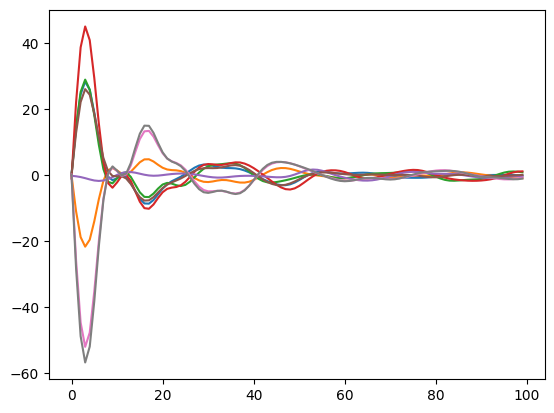

In [40]:
for channel in range(8):
    plt.plot(X_filtered[5, 0, channel, :100])
plt.show()

In [7]:
import numpy as np
import mne
from mne_icalabel import label_components

fs = 250  # Replace with your sampling frequency

# Shape: (trials, 1, channels, samples)
n_trials, _, n_channels, n_samples = X.shape

# --------------------------------------------------
# Channel information
# --------------------------------------------------
channel_names = [
    "F3",
    "Fz",
    "F4",
    "C3",
    "VEOG",   # Under-eye electrode
    "C4",
    "P3",
    "P4"
]

channel_types = [
    "eeg",
    "eeg",
    "eeg",
    "eeg",
    "eog",    # <-- Mark as EOG
    "eeg",
    "eeg",
    "eeg"
]

info = mne.create_info(
    ch_names=channel_names,
    sfreq=fs,
    ch_types=channel_types
)

# --------------------------------------------------
# Convert trials -> continuous recording
# --------------------------------------------------
continuous = (
    X[:, 0]
    .transpose(1, 0, 2)
    .reshape(n_channels, -1)
)

raw = mne.io.RawArray(continuous, info, verbose=False)

# Only EEG channels receive positions from the montage.
raw.set_montage("standard_1020", on_missing="ignore")

# --------------------------------------------------
# Filtering
# --------------------------------------------------
raw.filter(
    l_freq=1.0,
    h_freq=40.0,
    picks=["eeg", "eog"],
    verbose=False
)

raw.notch_filter(
    freqs=50,
    picks=["eeg", "eog"],
    verbose=False
)

# --------------------------------------------------
# ICA
# --------------------------------------------------
ica = mne.preprocessing.ICA(
    n_components=None,
    method="fastica",
    random_state=42,
    max_iter="auto"
)

# Fit ICA using EEG channels only.
ica.fit(raw, picks="eeg", verbose=False)

# Classify components
labels = label_components(raw, ica, method="iclabel")

exclude = []

for idx, (label, prob) in enumerate(
    zip(labels["labels"], labels["y_pred_proba"])
):
    print(f"{idx}: {label}: {prob:.3f}")
    if label != "brain" and prob >= 0.8:
        exclude.append(idx)

print("Components to remove:", exclude)

ica.exclude = exclude

raw_clean = raw.copy()
ica.apply(raw_clean)

# --------------------------------------------------
# Convert back to trials
# --------------------------------------------------
continuous_clean = raw_clean.get_data()

X_clean = (
    continuous_clean
    .reshape(n_channels, n_trials, n_samples)
    .transpose(1, 0, 2)
)

# Restore EEGNet shape
X_clean = X_clean[:, np.newaxis, :, :].astype(np.float32)

print("Original:", X.shape)
print("Cleaned :", X_clean.shape)

/home/carlos/.conda/envs/ml/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_25095/3827919186.py:85: RuntimeWarning: The provided Raw instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/tmp/ipykernel_25095/3827919186.py:85: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw, ica, method="iclabel")
/tmp/ipykernel_25095/3827919

0: brain: 0.989
1: brain: 0.965
2: brain: 0.993
3: other: 0.711
4: brain: 0.969
5: brain: 0.745
6: other: 0.746
Components to remove: []
Applying ICA to Raw instance
    Transforming to ICA space (7 components)
    Zeroing out 0 ICA components
    Projecting back using 7 PCA components
Original: (30, 1, 8, 1000)
Cleaned : (30, 1, 8, 1000)


In [32]:
import numpy as np
import mne

fs = 250  # Sampling frequency

# Shape: (trials, 1, channels, samples)
n_trials, _, n_channels, n_samples = X.shape

# --------------------------------------------------
# Channel information
# --------------------------------------------------
channel_names = [
    "F3",
    "Fz",
    "F4",
    "C3",
    "VEOG",      # Under-eye electrode
    "C4",
    "P3",
    "P4"
]

channel_types = [
    "eeg",
    "eeg",
    "eeg",
    "eeg",
    "eog",
    "eeg",
    "eeg",
    "eeg"
]

info = mne.create_info(
    ch_names=channel_names,
    sfreq=fs,
    ch_types=channel_types
)

# --------------------------------------------------
# Convert trials -> continuous recording
# --------------------------------------------------
continuous = (
    X[:, 0]
    .transpose(1, 0, 2)
    .reshape(n_channels, -1)
)

raw = mne.io.RawArray(continuous, info, verbose=False)
raw.set_montage("standard_1020", on_missing="ignore")

# --------------------------------------------------
# Filtering
# --------------------------------------------------
raw.filter(
    l_freq=1.0,
    h_freq=40.0,
    picks=["eeg", "eog"],
    verbose=False
)

raw.notch_filter(
    freqs=50,
    picks=["eeg", "eog"],
    verbose=False
)

# --------------------------------------------------
# ICA
# --------------------------------------------------
ica = mne.preprocessing.ICA(
    n_components=None,
    method="fastica",
    random_state=42,
    max_iter="auto"
)

# Fit only EEG channels
ica.fit(raw, picks="eeg", verbose=False)

# --------------------------------------------------
# Detect blink components using VEOG
# --------------------------------------------------
eog_indices, eog_scores = ica.find_bads_eog(
    raw,
    ch_name="VEOG",
    threshold="auto"
)

print("Detected blink components:", eog_indices)

ica.exclude = eog_indices

# --------------------------------------------------
# Apply ICA
# --------------------------------------------------
raw_clean = raw.copy()
ica.apply(raw_clean)

# --------------------------------------------------
# Convert back to trials
# --------------------------------------------------
continuous_clean = raw_clean.get_data()

X_clean = (
    continuous_clean
    .reshape(n_channels, n_trials, n_samples)
    .transpose(1, 0, 2)
)

# Restore EEGNet shape
X_clean = X_clean[:, np.newaxis, :, :].astype(np.float32)

print("Original:", X.shape)
print("Cleaned :", X_clean.shape)

Using EOG channel: VEOG
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2500 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
-

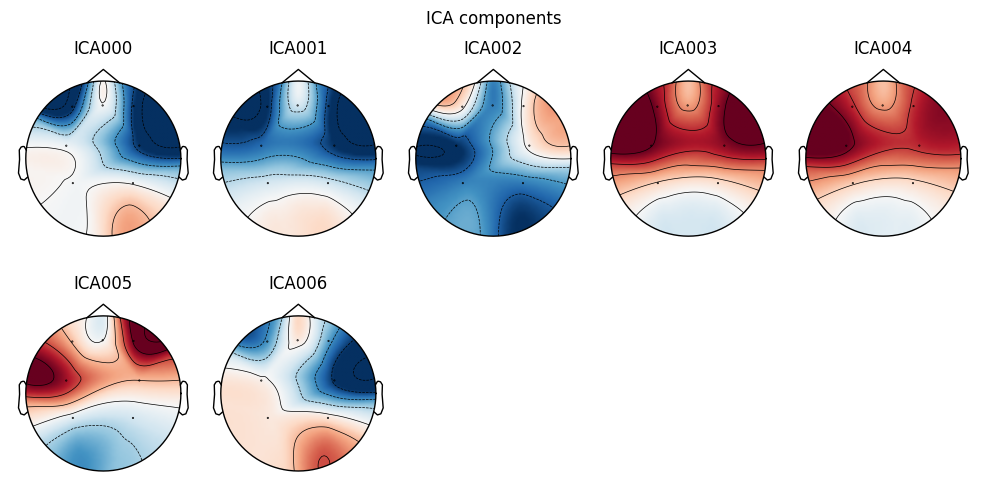

Creating RawArray with float64 data, n_channels=8, n_times=30000
    Range : 0 ... 29999 =      0.000 ...   119.996 secs
Ready.


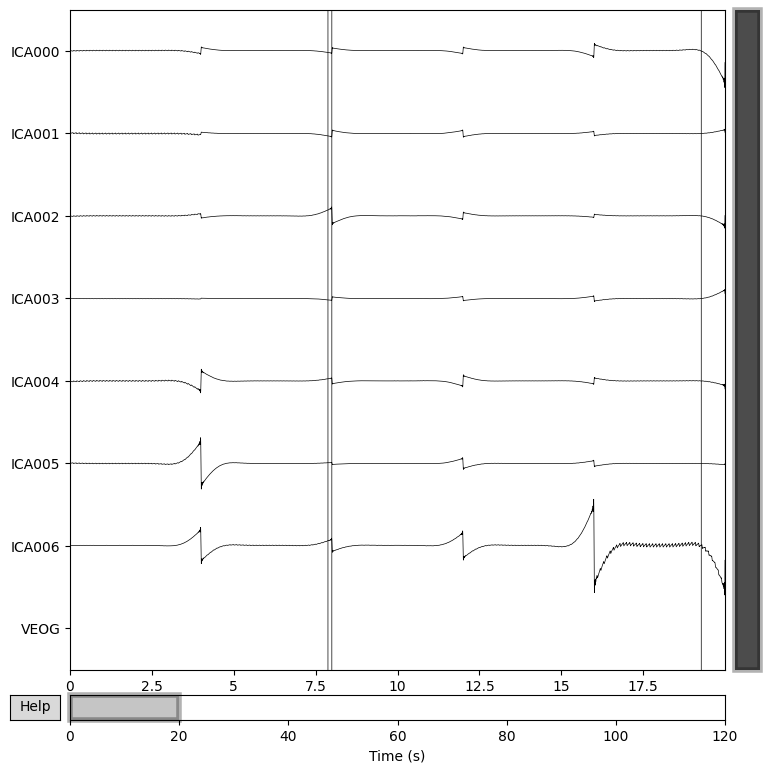

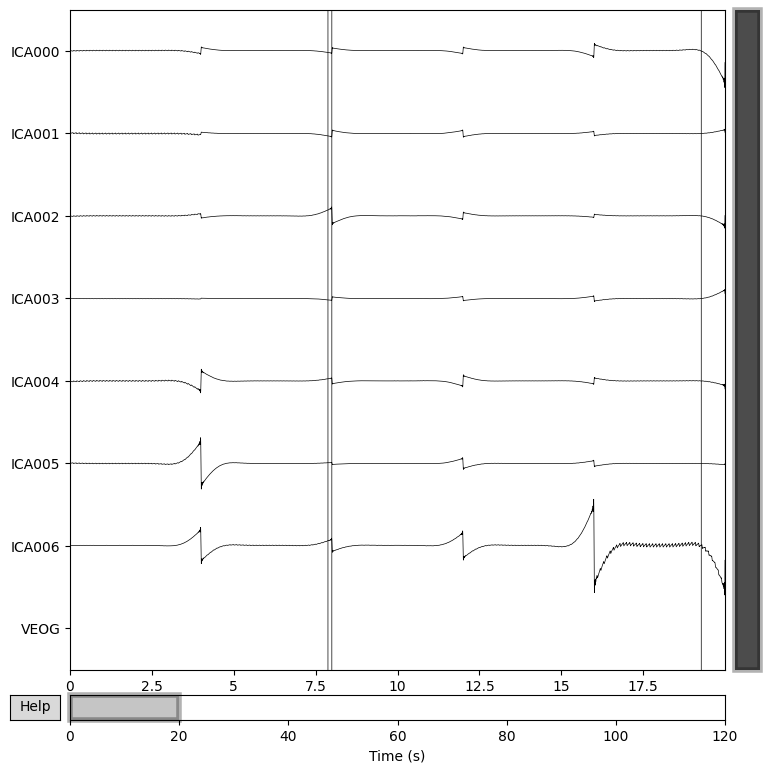

In [33]:
ica.plot_components()
ica.plot_sources(raw)

In [34]:
# 2. Convert to PyTorch Tensors
X_tensor = torch.tensor(X_clean, dtype=torch.float32)


# 3. Encode your string labels into numerical classes for PyTorch
unique_labels = np.unique(y)
label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
y_mapped = np.array([label_to_index[label] for label in y])
y_tensor = torch.tensor(y_mapped, dtype=torch.long)


X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.33, random_state=123)

mean = X_train.mean(axis=(0, 3), keepdims=True)
std = X_train.std(axis=(0, 3), keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# 4. Ready for training!
dataset = TensorDataset(X_train, y_train)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

In [35]:
model = EEGNet(n_classes=3, electrode_channels=8,
               sample_length=1000, dropout_rate=0.9, kernel_length=32).to(device=device)
criterion = torch.nn.CrossEntropyLoss()
optim = torch.optim.Adam(params=model.parameters(), lr=3e-4)

In [39]:
num_epochs = 100

for epoch in range(num_epochs):
    running_loss = 0.0
    outputs: torch.Tensor = torch.tensor([])
    labels: torch.Tensor = torch.tensor([])
    # 4. Inner loop to iterate over DataLoader batches
    for inputs, labels in dataloader:
        # inputs = inputs.unsqueeze(1).to(device)
        labels = labels.to(device)
        inputs = inputs.to(device)
        # 5. Clear previous gradients
        optim.zero_grad()

        # 6. Forward pass through network
        outputs = model(inputs)

        # 7. Compute loss metrics
        loss = criterion(outputs, labels)

        # 8. Backward pass (calculate gradients)
        loss.backward()

        # 9. Update network weights
        optim.step()

        # 10. Track ongoing performance
        running_loss += loss.item()

        model.apply_max_norm()

    if epoch % 10 == 0:
        model.eval()
        y_pred = model.forward(X_train.to(device))

        acc = accuracy_score(y_pred.detach().cpu().numpy().argmax(axis=1),
                             y_train.detach().cpu().numpy())
        print(f"Train: Acc: {acc} | Loss: {running_loss}")

        y_pred = model.forward(X_test.to(device))
        acc = accuracy_score(y_pred.detach().cpu().numpy().argmax(axis=1),
                             y_test.detach().cpu().numpy())
        loss = criterion(y_pred, y_test.to(device))
        print(f"Test: Acc: {acc} | Loss: {loss}")
        print("-"*10)

Train: Acc: 0.75 | Loss: 1.342954307794571
Test: Acc: 0.3 | Loss: 4.2399163246154785
----------
Train: Acc: 0.75 | Loss: 1.3763614892959595
Test: Acc: 0.3 | Loss: 4.31152868270874
----------
Train: Acc: 0.75 | Loss: 1.32464137673378
Test: Acc: 0.3 | Loss: 4.422372341156006
----------
Train: Acc: 0.8 | Loss: 1.1761330962181091
Test: Acc: 0.3 | Loss: 4.589972496032715
----------
Train: Acc: 0.75 | Loss: 1.1416335999965668
Test: Acc: 0.3 | Loss: 4.607558250427246
----------
Train: Acc: 0.75 | Loss: 1.0767824947834015
Test: Acc: 0.3 | Loss: 4.790371894836426
----------
Train: Acc: 0.75 | Loss: 1.0687661468982697
Test: Acc: 0.3 | Loss: 5.004373073577881
----------
Train: Acc: 0.75 | Loss: 0.9759863615036011
Test: Acc: 0.3 | Loss: 5.0302276611328125
----------
Train: Acc: 0.85 | Loss: 0.9407019019126892
Test: Acc: 0.3 | Loss: 4.993470191955566
----------
Train: Acc: 0.9 | Loss: 0.7684666588902473
Test: Acc: 0.3 | Loss: 5.294737339019775
----------


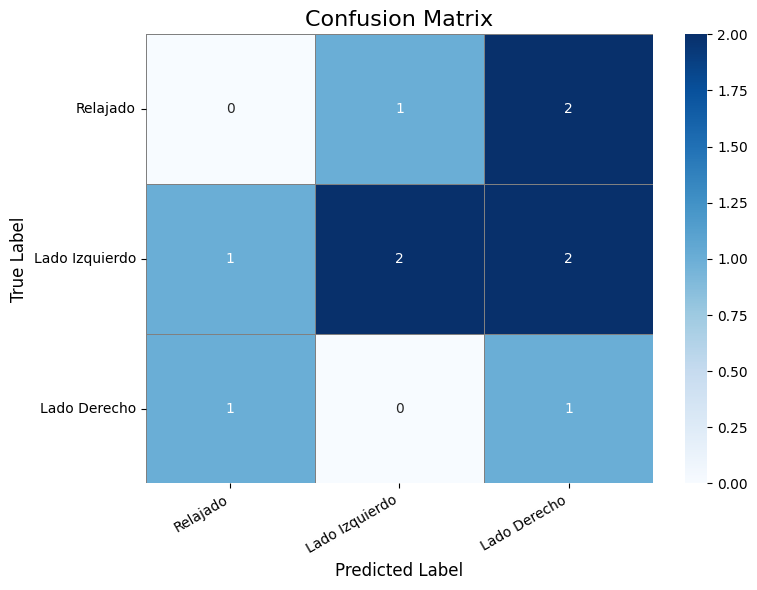

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

ACTIONS = ["Relajado", "Lado Izquierdo", "Lado Derecho"]

# Predictions
model.eval()
with torch.no_grad():
    y_pred = model(X_test.to(device))

y_true = y_test.cpu().numpy()
y_pred = y_pred.cpu().numpy().argmax(axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=ACTIONS,
    yticklabels=ACTIONS,
    linewidths=0.5,
    linecolor="gray"
)

plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [77]:
torch.save(model, "55.pth")

In [72]:
torch.load("80.pth", weights_only=False)

EEGNet(
  (block1_conv1): Conv2d(1, 8, kernel_size=(1, 32), stride=(1, 1), padding=same, bias=False)
  (block1_bn1): BatchNorm2d(8, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
  (block1_conv2): Conv2d(8, 16, kernel_size=(5, 1), stride=(1, 1), groups=8, bias=False)
  (block1_bn2): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
  (block1_elu): ELU(alpha=1.0)
  (block1_pool): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
  (block1_dropout): Dropout(p=0.5, inplace=False)
  (block2_conv1): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=same, groups=16, bias=False)
  (block2_conv2): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (block2_bn): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
  (block2_elu): ELU(alpha=1.0)
  (block2_pool): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
  (block2_dropout): Dropout(p=0.5, inplace=F